<a href="https://colab.research.google.com/github/francji1/01ZLMA/blob/main/code/01ZLMA_ex02_HW_solution_MV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.special import gammaln
import statsmodels.api as sm
from statsmodels.genmod.families import Poisson, Gamma, Binomial
from statsmodels.genmod.families.links import Identity, Log, InversePower, Logit
import warnings
warnings.filterwarnings('ignore')

np.set_printoptions(precision=6, suppress=True)
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

In [2]:
# Example 1 data (Poisson identity link, Dobson 4.4)
x_raw = np.array([-1, -1, 0, 0, 0, 0, 1, 1, 1])
Y1 = np.array([2, 3, 6, 7, 8, 9, 10, 12, 15])
n1 = len(x_raw)
X1 = np.column_stack((np.ones(n1), x_raw))

# statsmodels reference for comparison
model_sm1 = sm.GLM(Y1, X1, family=Poisson(link=Identity()))
results_sm1 = model_sm1.fit()


In [3]:
# Load AIDS data from GitHub
aids_url = "https://raw.githubusercontent.com/francji1/01ZLMA/main/data/aids.csv"
aids = pd.read_csv(aids_url)
aids['time_index'] = np.arange(1, len(aids) + 1)
aids

,year,quarter,cases,time_index
0,1984,1,1,1
1,1984,2,6,2
2,1984,3,16,3
3,1984,4,23,4
4,1985,1,27,5
5,1985,2,39,6
6,1985,3,31,7
7,1985,4,30,8
8,1986,1,43,9
9,1986,2,51,10


In [4]:
# Setup
Y2 = aids['cases'].values.astype(float)
X2 = np.column_stack((np.ones(len(Y2)), np.log(aids['time_index'].values)))
n2 = len(Y2)

# Functions for Poisson log-link
def calc_mu_log(X, beta):
    """mu = exp(X @ beta)"""
    return np.exp(X @ beta)

def calc_W_inv_log(X, beta):
    """W_inv = diag(mu) for Poisson log-link"""
    mu = calc_mu_log(X, beta)
    return np.diag(mu)

def calc_Z_log(X, Y, beta):
    """Working response Z = eta + (y - mu)/mu for log-link"""
    eta = X @ beta
    mu = np.exp(eta)
    return eta + (Y - mu) / mu

def poisson_loglik(X, Y, beta):
    """Poisson log-likelihood"""
    mu = calc_mu_log(X, beta)
    return np.sum(Y * np.log(mu) - mu - gammaln(Y + 1))

In [5]:
def IWLS_poisson_log(X, Y, beta_init, max_iter=100, tol=1e-8):
    """IWLS for Poisson GLM with log link"""
    beta = beta_init.copy()
    beta_history = [beta.copy()]
    ll_history = [poisson_loglik(X, Y, beta)]
    
    for i in range(max_iter):
        W_inv = calc_W_inv_log(X, beta)
        Z = calc_Z_log(X, Y, beta)
        beta_new = np.linalg.solve(X.T @ W_inv @ X, X.T @ W_inv @ Z)
        beta_history.append(beta_new.copy())
        ll_history.append(poisson_loglik(X, Y, beta_new))
        if np.max(np.abs(beta_new - beta)) < tol:
            break
        beta = beta_new
    return np.array(beta_history), np.array(ll_history)

In [6]:
def fisher_scoring_poisson_log(x, Y, beta_init, max_iter=100, tol=1e-8):
    """Fisher Scoring for Poisson log-link (direct computation from lecture)"""
    beta = beta_init.copy()
    beta_history = [beta.copy()]
    X_design = np.column_stack((np.ones(len(Y)), x))
    ll_history = [poisson_loglik(X_design, Y, beta)]
    
    for i in range(max_iter):
        pom = np.exp(beta[1] * x)
        # Fisher information matrix
        a11 = np.exp(beta[0]) * np.sum(pom)
        a12 = np.exp(beta[0]) * np.sum(x * pom)
        a22 = np.exp(beta[0]) * np.sum(x**2 * pom)
        FM = np.array([[a11, a12], [a12, a22]])
        # Score vector
        u1 = np.sum(Y) - np.exp(beta[0]) * np.sum(pom)
        u2 = np.sum(x * Y) - np.exp(beta[0]) * np.sum(x * pom)
        SV = np.array([u1, u2])
        # Update
        beta_new = beta + np.linalg.solve(FM, SV)
        beta_history.append(beta_new.copy())
        ll_history.append(poisson_loglik(X_design, Y, beta_new))
        if np.max(np.abs(beta_new - beta)) < tol:
            break
        beta = beta_new
    return np.array(beta_history), np.array(ll_history)

In [7]:
def newton_raphson_poisson_log(X, Y, beta_init, max_iter=100, tol=1e-8):
    """Newton-Raphson for Poisson log-link. For canonical link, NR = Fisher Scoring."""
    beta = beta_init.copy()
    beta_history = [beta.copy()]
    ll_history = [poisson_loglik(X, Y, beta)]
    
    for i in range(max_iter):
        mu = calc_mu_log(X, beta)
        # Score vector: U = X^T (y - mu)
        U = X.T @ (Y - mu)
        # Observed Hessian: H = -X^T diag(mu) X (for canonical link = -I)
        H = -X.T @ np.diag(mu) @ X
        # NR update: beta_new = beta - H^{-1} U
        beta_new = beta - np.linalg.solve(H, U)
        beta_history.append(beta_new.copy())
        ll_history.append(poisson_loglik(X, Y, beta_new))
        if np.max(np.abs(beta_new - beta)) < tol:
            break
        beta = beta_new
    return np.array(beta_history), np.array(ll_history)

In [8]:
x_log = np.log(aids['time_index'].values)


In [9]:
# statsmodels reference for AIDS data (Poisson log link)
model_sm2 = sm.GLM(Y2, X2, family=Poisson(link=Log()))
results_sm2 = model_sm2.fit()


---
# 11. Homework

1. Implement Newton-Raphson, Fisher Scoring, and IWLS for **Example 1** (Poisson identity link). Compare convergence of all three methods.

2. Try different initial values for Example 2 (AIDS data). How sensitive are the methods to initialization?

3. Implement stochastic gradient descent (SGD) for the Poisson log-link model and compare convergence with IWLS.

## Homework 1: Newton-Raphson, Fisher Scoring, and IWLS for Poisson Identity Link

Initial beta: [7.5      4.916667]
Newton-Raphson:  [7.451633 4.9353  ]  (4 iterations)
Fisher Scoring:  [7.451633 4.9353  ]  (5 iterations)
IWLS:            [7.451633 4.9353  ]  (5 iterations)
statsmodels:     [7.451633 4.9353  ]

Iteration details:
Iter |             Newton-Raphson |             Fisher Scoring |                       IWLS
--------------------------------------------------------------------------------------------
   0 | [  7.500000,   4.916667] | [  7.500000,   4.916667] | [  7.500000,   4.916667]
   1 | [  7.450965,   4.936290] | [  7.451665,   4.935016] | [  7.451665,   4.935016]
   2 | [  7.451633,   4.935301] | [  7.451633,   4.935299] | [  7.451633,   4.935299]
   3 | [  7.451633,   4.935300] | [  7.451633,   4.935300] | [  7.451633,   4.935300]
   4 | [  7.451633,   4.935300] | [  7.451633,   4.935300] | [  7.451633,   4.935300]
   5 |                            | [  7.451633,   4.935300] | [  7.451633,   4.935300]


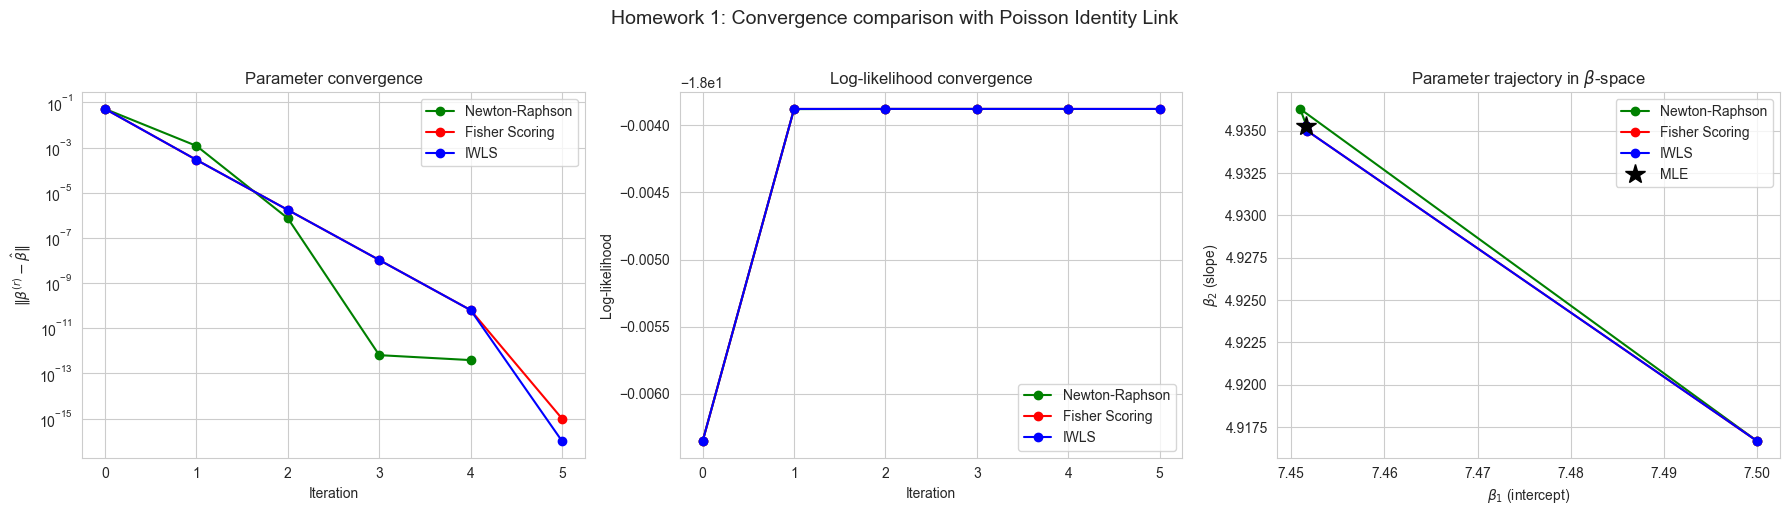

In [10]:
def poisson_identity_loglik(X, Y, beta):
    """Poisson log-likelihood with identity link: mu = X @ beta"""
    mu = X @ beta
    if np.any(mu <= 0):
        return -np.inf
    return np.sum(Y * np.log(mu) - mu - gammaln(Y + 1))

# --- Newton-Raphson ---
def newton_raphson_poisson_identity(X, Y, beta_init, max_iter=100, tol=1e-8):
    """
    Newton-Raphson for Poisson with identity link.
    Observed Hessian: H = -X^T diag(y_i / mu_i^2) X
    Score:            U = X^T diag(1/mu_i) (y - mu)
    Update:           beta_new = beta - H^{-1} U
    """
    beta = beta_init.copy()
    beta_history = [beta.copy()]
    ll_history = [poisson_identity_loglik(X, Y, beta)]

    for it in range(max_iter):
        mu = X @ beta
        # Score vector
        U = X.T @ ((Y - mu) / mu)
        # Observed Hessian
        H = -X.T @ np.diag(Y / mu**2) @ X
        # NR update: beta - H^{-1} U
        beta_new = beta - np.linalg.solve(H, U)
        beta_history.append(beta_new.copy())
        ll_history.append(poisson_identity_loglik(X, Y, beta_new))
        if np.max(np.abs(beta_new - beta)) < tol:
            break
        beta = beta_new
    return np.array(beta_history), np.array(ll_history)

# --- Fisher Scoring ---
def fisher_scoring_poisson_identity(X, Y, beta_init, max_iter=100, tol=1e-8):
    """
    Fisher Scoring for Poisson with identity link.
    Fisher Information: I = X^T diag(1/mu_i) X
    Score:              U = X^T diag(1/mu_i) (y - mu)
    Update:             beta_new = beta + I^{-1} U
    """
    beta = beta_init.copy()
    beta_history = [beta.copy()]
    ll_history = [poisson_identity_loglik(X, Y, beta)]

    for it in range(max_iter):
        mu = X @ beta
        # Score vector
        U = X.T @ ((Y - mu) / mu)
        # Fisher information matrix
        I_mat = X.T @ np.diag(1.0 / mu) @ X
        # FS update: beta + I^{-1} U
        beta_new = beta + np.linalg.solve(I_mat, U)
        beta_history.append(beta_new.copy())
        ll_history.append(poisson_identity_loglik(X, Y, beta_new))
        if np.max(np.abs(beta_new - beta)) < tol:
            break
        beta = beta_new
    return np.array(beta_history), np.array(ll_history)

# --- IWLS (with log-likelihood tracking) ---
def IWLS_poisson_identity_full(X, Y, beta_init, max_iter=100, tol=1e-8):
    """
    IWLS for Poisson with identity link.
    W^{-1} = diag(1/mu_i),  Z = y  (working response = observed data for identity link)
    Update: beta_new = (X^T W^{-1} X)^{-1} X^T W^{-1} y
    Equivalent to Fisher Scoring.
    """
    beta = beta_init.copy()
    beta_history = [beta.copy()]
    ll_history = [poisson_identity_loglik(X, Y, beta)]

    for it in range(max_iter):
        mu = X @ beta
        W_inv = np.diag(1.0 / mu)
        # For identity link, working response Z = y
        beta_new = np.linalg.solve(X.T @ W_inv @ X, X.T @ W_inv @ Y)
        beta_history.append(beta_new.copy())
        ll_history.append(poisson_identity_loglik(X, Y, beta_new))
        if np.max(np.abs(beta_new - beta)) < tol:
            break
        beta = beta_new
    return np.array(beta_history), np.array(ll_history)

# --- Run all three methods on Example 1 data ---
beta_init1 = np.array([np.mean(Y1[x_raw == 0]),
                       (np.mean(Y1[x_raw == 1]) - np.mean(Y1[x_raw == -1])) / 2])  # Group means

hist_nr1, ll_nr1 = newton_raphson_poisson_identity(X1, Y1, beta_init1)
hist_fs1, ll_fs1 = fisher_scoring_poisson_identity(X1, Y1, beta_init1)
hist_iwls1, ll_iwls1 = IWLS_poisson_identity_full(X1, Y1, beta_init1)

print(f"Initial beta: {beta_init1}")
print(f"Newton-Raphson:  {hist_nr1[-1]}  ({len(hist_nr1)-1} iterations)")
print(f"Fisher Scoring:  {hist_fs1[-1]}  ({len(hist_fs1)-1} iterations)")
print(f"IWLS:            {hist_iwls1[-1]}  ({len(hist_iwls1)-1} iterations)")
print(f"statsmodels:     {results_sm1.params}")

# --- Iteration-by-iteration comparison ---
print("\nIteration details:")
print(f"{'Iter':>4} | {'Newton-Raphson':>26} | {'Fisher Scoring':>26} | {'IWLS':>26}")
print("-" * 92)
max_it = max(len(hist_nr1), len(hist_fs1), len(hist_iwls1))
for i in range(max_it):
    nr_s = f"[{hist_nr1[i,0]:10.6f}, {hist_nr1[i,1]:10.6f}]" if i < len(hist_nr1) else " " * 26
    fs_s = f"[{hist_fs1[i,0]:10.6f}, {hist_fs1[i,1]:10.6f}]" if i < len(hist_fs1) else " " * 26
    iw_s = f"[{hist_iwls1[i,0]:10.6f}, {hist_iwls1[i,1]:10.6f}]" if i < len(hist_iwls1) else " " * 26
    print(f"{i:>4} | {nr_s} | {fs_s} | {iw_s}")

# --- Convergence comparison plots ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
beta_final1 = hist_iwls1[-1]

# 1. ||beta - beta_hat|| convergence
for hist, label, color in [(hist_nr1, 'Newton-Raphson', 'green'),
                            (hist_fs1, 'Fisher Scoring', 'red'),
                            (hist_iwls1, 'IWLS', 'blue')]:
    errors = np.sqrt(np.sum((hist - beta_final1)**2, axis=1))
    axes[0].semilogy(errors + 1e-16, 'o-', label=label, color=color)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('$\\|\\beta^{(r)} - \\hat{\\beta}\\|$')
axes[0].set_title('Parameter convergence')
axes[0].legend()

# 2. Log-likelihood convergence
for ll, label, color in [(ll_nr1, 'Newton-Raphson', 'green'),
                          (ll_fs1, 'Fisher Scoring', 'red'),
                          (ll_iwls1, 'IWLS', 'blue')]:
    axes[1].plot(ll, 'o-', label=label, color=color)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Log-likelihood')
axes[1].set_title('Log-likelihood convergence')
axes[1].legend()

# 3. Parameter trajectory in beta-space
for hist, label, color in [(hist_nr1, 'Newton-Raphson', 'green'),
                            (hist_fs1, 'Fisher Scoring', 'red'),
                            (hist_iwls1, 'IWLS', 'blue')]:
    axes[2].plot(hist[:, 0], hist[:, 1], 'o-', label=label, color=color, markersize=6)
axes[2].plot(*beta_final1, 'k*', markersize=15, label='MLE')
axes[2].set_xlabel('$\\beta_1$ (intercept)')
axes[2].set_ylabel('$\\beta_2$ (slope)')
axes[2].set_title('Parameter trajectory in $\\beta$-space')
axes[2].legend()

plt.suptitle('Homework 1: Convergence comparison with Poisson Identity Link', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Homework 2: Sensitivity to Initial Values

       OLS on log(Y): beta0 = [  0.69,   1.45]  ->  IWLS 4 it, FS 4 it, NR 4 it  => beta_hat = [0.995998, 1.326610]
          Zero slope: beta0 = [  2.00,   0.00]  ->  IWLS 16 it, FS 16 it, NR 16 it  => beta_hat = [0.995998, 1.326610]
        Large values: beta0 = [  5.00,   5.00]  ->  IWLS 20 it, FS 20 it, NR 20 it  => beta_hat = [0.995998, 1.326610]
        Small values: beta0 = [  0.10,   0.10]  ->  IWLS 76 it, FS 76 it, NR 76 it  => beta_hat = [0.995998, 1.326610]
      Negative slope: beta0 = [  3.00,  -1.00]  ->  IWLS 60 it, FS 60 it, NR 60 it  => beta_hat = [0.995998, 1.326610]
           Near-zero: beta0 = [  0.01,   0.01]  ->  IWLS 100 it, FS 100 it, NR 100 it  => beta_hat = [0.800533, 1.439963]

     statsmodels ref: [0.995998 1.32661 ]


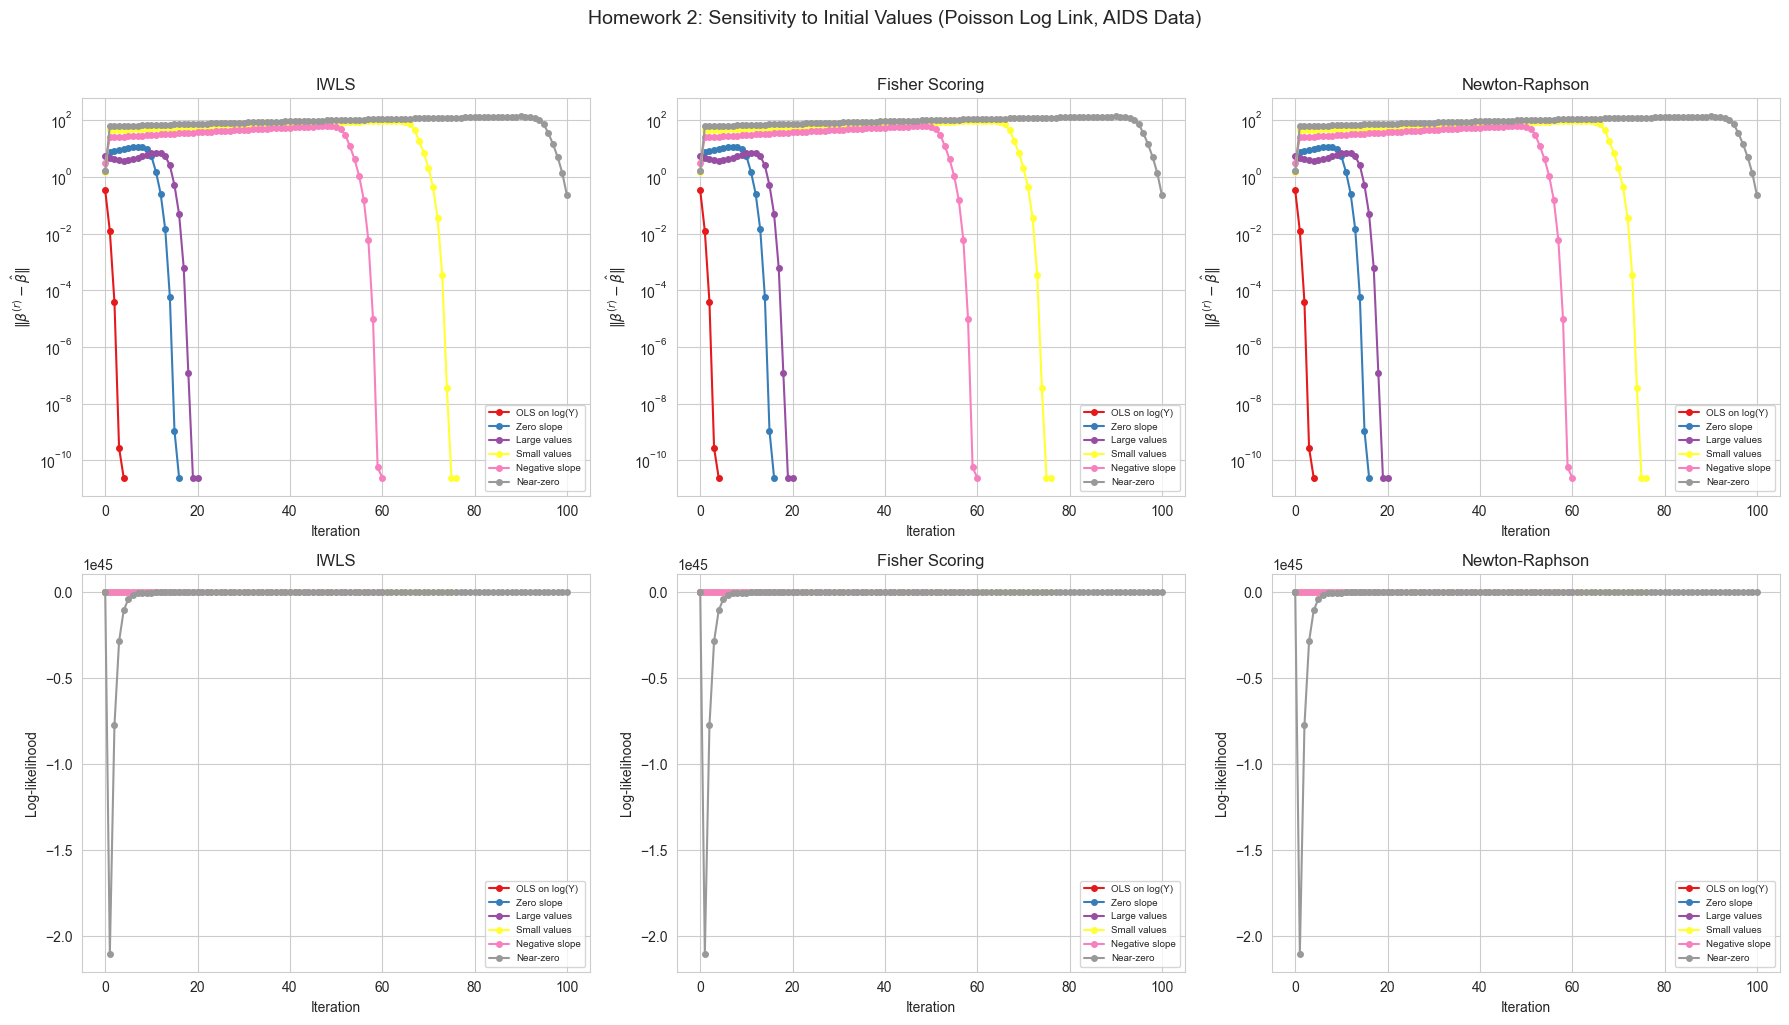


Summary: iterations to convergence (tol=1e-8)
Initial values       |           beta_0 |   IWLS |     FS |     NR |               Converged to
---------------------------------------------------------------------------------------------------------
OLS on log(Y)        | [  0.69,  1.45] |      4 |      4 |      4 | [0.995998, 1.326610]
Zero slope           | [  2.00,  0.00] |     16 |     16 |     16 | [0.995998, 1.326610]
Large values         | [  5.00,  5.00] |     20 |     20 |     20 | [0.995998, 1.326610]
Small values         | [  0.10,  0.10] |     76 |     76 |     76 | [0.995998, 1.326610]
Negative slope       | [  3.00, -1.00] |     60 |     60 |     60 | [0.995998, 1.326610]
Near-zero            | [  0.01,  0.01] |    100 |    100 |    100 | [0.800533, 1.439963]


In [11]:
# Define a set of diverse initial values
init_configs = {
    'OLS on log(Y)':   np.linalg.lstsq(X2, np.log(Y2), rcond=None)[0],
    'Zero slope':      np.array([2.0, 0.0]),
    'Large values':    np.array([5.0, 5.0]),
    'Small values':    np.array([0.1, 0.1]),
    'Negative slope':  np.array([3.0, -1.0]),
    'Near-zero':       np.array([0.01, 0.01]),
}

# Run all three methods from each initialization
results_hw2 = {}
for name, beta0 in init_configs.items():
    try:
        h_iwls, ll_iwls = IWLS_poisson_log(X2, Y2, beta0)
        h_fs, ll_fs = fisher_scoring_poisson_log(x_log, Y2, beta0)
        h_nr, ll_nr = newton_raphson_poisson_log(X2, Y2, beta0)
        results_hw2[name] = {
            'init': beta0,
            'IWLS': (h_iwls, ll_iwls),
            'Fisher Scoring': (h_fs, ll_fs),
            'Newton-Raphson': (h_nr, ll_nr),
        }
        print(f"{name:>20}: beta0 = [{beta0[0]:6.2f}, {beta0[1]:6.2f}]  ->  "
              f"IWLS {len(h_iwls)-1} it, FS {len(h_fs)-1} it, NR {len(h_nr)-1} it  "
              f"=> beta_hat = [{h_iwls[-1][0]:.6f}, {h_iwls[-1][1]:.6f}]")
    except Exception as e:
        print(f"{name:>20}: beta0 = [{beta0[0]:6.2f}, {beta0[1]:6.2f}]  ->  FAILED: {e}")
        results_hw2[name] = None

print(f"\n{'statsmodels ref':>20}: {results_sm2.params}")

# --- Convergence plots ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
beta_ref = results_sm2.params
methods = ['IWLS', 'Fisher Scoring', 'Newton-Raphson']
colors_map = plt.cm.Set1(np.linspace(0, 1, len(init_configs)))

# Top row: ||beta - beta_hat|| convergence for each method
for j, method in enumerate(methods):
    for (name, res), color in zip(results_hw2.items(), colors_map):
        if res is not None:
            hist, ll = res[method]
            errors = np.sqrt(np.sum((hist - beta_ref)**2, axis=1))
            axes[0, j].semilogy(errors + 1e-16, 'o-', label=name, color=color, markersize=4)
    axes[0, j].set_xlabel('Iteration')
    axes[0, j].set_ylabel('$\\|\\beta^{(r)} - \\hat{\\beta}\\|$')
    axes[0, j].set_title(f'{method}')
    axes[0, j].legend(fontsize=7)

# Bottom row: log-likelihood convergence for each method
for j, method in enumerate(methods):
    for (name, res), color in zip(results_hw2.items(), colors_map):
        if res is not None:
            hist, ll = res[method]
            axes[1, j].plot(ll, 'o-', label=name, color=color, markersize=4)
    axes[1, j].set_xlabel('Iteration')
    axes[1, j].set_ylabel('Log-likelihood')
    axes[1, j].set_title(f'{method}')
    axes[1, j].legend(fontsize=7)

plt.suptitle('Homework 2: Sensitivity to Initial Values (Poisson Log Link, AIDS Data)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# --- Summary table ---
print("\nSummary: iterations to convergence (tol=1e-8)")
print(f"{'Initial values':<20} | {'beta_0':>16} | {'IWLS':>6} | {'FS':>6} | {'NR':>6} | {'Converged to':>26}")
print("-" * 105)
for name, res in results_hw2.items():
    if res is not None:
        b0 = res['init']
        n_iwls = len(res['IWLS'][0]) - 1
        n_fs   = len(res['Fisher Scoring'][0]) - 1
        n_nr   = len(res['Newton-Raphson'][0]) - 1
        bf     = res['IWLS'][0][-1]
        print(f"{name:<20} | [{b0[0]:6.2f},{b0[1]:6.2f}] | {n_iwls:>6} | {n_fs:>6} | {n_nr:>6} | [{bf[0]:.6f}, {bf[1]:.6f}]")
    else:
        b0 = init_configs[name]
        print(f"{name:<20} | [{b0[0]:6.2f},{b0[1]:6.2f}] | {'FAIL':>6} | {'FAIL':>6} | {'FAIL':>6} |")

## Homework 3: Stochastic Gradient Descent for Poisson Log-Link

IWLS uses **second-order** (curvature) information via  $I^{-1}$ and converges in few iterations; SGD uses only **first-order** (gradient) information and needs many more steps, but scales better to large datasets.

### Key design choice: learning rate schedule

The schedule must satisfy the **Robbins-Monro conditions** for SGD convergence:
- $\sum_t \eta_t = \infty$ (can reach any point) and $\sum_t \eta_t^2 < \infty$ (noise dies out).
- **Exponential decay** $\eta_t = \eta_0 \cdot r^t$ gives a *finite* sum $\eta_0/(1-r)$, violating the first condition — SGD freezes before reaching the MLE.
- **Inverse-time decay** $\eta_t = \eta_0 / (1 + \alpha\, t)$ satisfies both conditions.

Initial beta (OLS on log(Y)): [0.685834 1.454341]

Final estimates:
  SGD (batch=1):    [0.992911 1.328128]   (2000 epochs)
  SGD (batch=4):    [0.985872 1.330764]   (2000 epochs)
  SGD (full batch): [0.934144 1.349918]   (2000 epochs)
  IWLS:             [0.995998 1.32661 ]   (4 iterations)
  statsmodels:      [0.995998 1.32661 ]


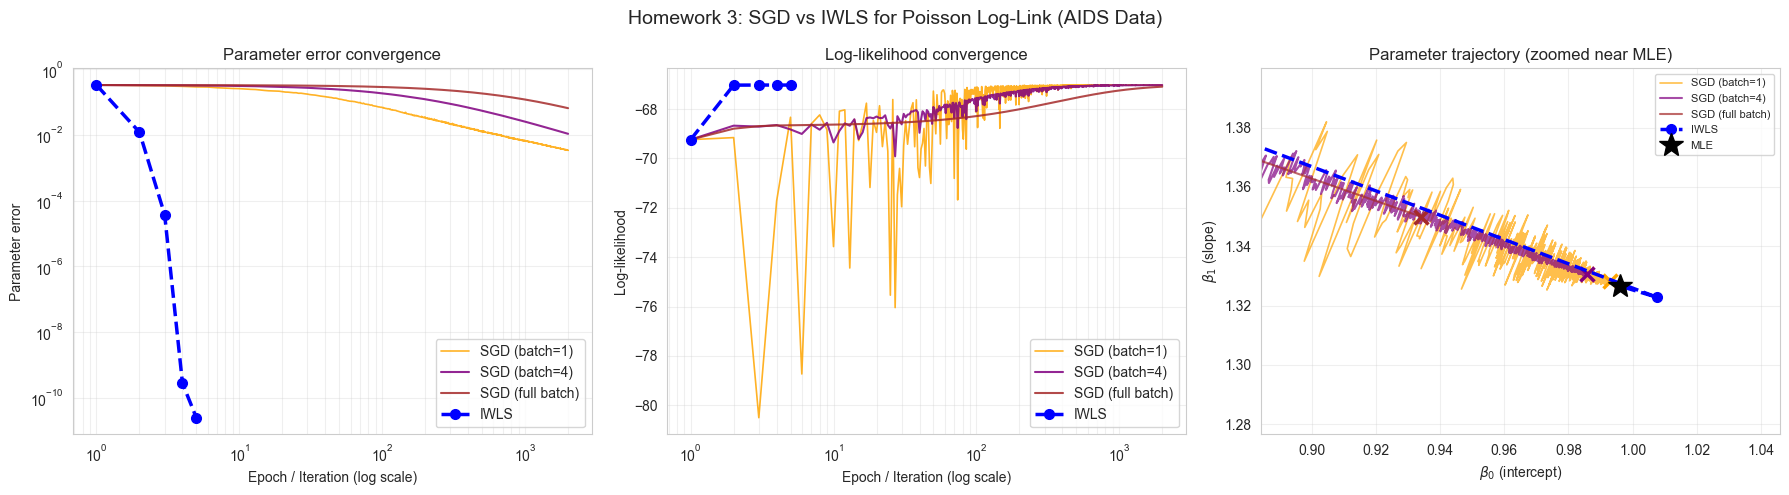

In [12]:
def sgd_poisson_log(X, Y, beta_init, n_epochs=500, lr=0.01, lr_decay=1e-3,
                    batch_size=1, max_grad_norm=200.0, seed=42):
    """
    Stochastic Gradient Descent for Poisson GLM with log link.

    Per-observation gradient (gradient ascent on log-likelihood):
        grad_i = (y_i - mu_i) * x_i,  where mu_i = exp(x_i^T beta)

    Parameters:
        batch_size: 1 = pure SGD, n = full-batch GD, in between = mini-batch
        lr:         base learning rate
        lr_decay:   inverse-time decay rate: lr_t = lr / (1 + lr_decay * step)
                    Satisfies Robbins-Monro: sum(lr_t)->inf, sum(lr_t^2)<inf
        max_grad_norm: gradient clipping threshold (exp link can cause gradient explosion)
    """
    rng = np.random.default_rng(seed)
    n = len(Y)
    beta = beta_init.copy()
    beta_history = [beta.copy()]
    ll_history = [poisson_loglik(X, Y, beta)]
    step = 0

    for epoch in range(n_epochs):
        indices = rng.permutation(n)
        for start in range(0, n, batch_size):
            idx = indices[start:start + batch_size]
            x_batch = X[idx]
            y_batch = Y[idx]
            mu_batch = np.exp(x_batch @ beta)
            # Mini-batch gradient (averaged over batch)
            grad = x_batch.T @ (y_batch - mu_batch) / len(idx)
            # Clip gradient to prevent divergence (exp link is sensitive)
            grad_norm = np.linalg.norm(grad)
            if grad_norm > max_grad_norm:
                grad = grad * (max_grad_norm / grad_norm)
            # Inverse-time learning rate (Robbins-Monro compliant):
            #   sum(1/(1+a*t)) ~ ln(t)/a -> inf,  sum(1/(1+a*t)^2) < inf
            step += 1
            current_lr = lr / (1.0 + lr_decay * step)
            beta = beta + current_lr * grad

        beta_history.append(beta.copy())
        ll_history.append(poisson_loglik(X, Y, beta))

    return np.array(beta_history), np.array(ll_history)

# --- Run SGD variants and IWLS ---
beta_init_sgd = np.linalg.lstsq(X2, np.log(Y2), rcond=None)[0]
print(f"Initial beta (OLS on log(Y)): {beta_init_sgd}")

# SGD with different batch sizes
hist_sgd1, ll_sgd1 = sgd_poisson_log(X2, Y2, beta_init_sgd,
                                      n_epochs=2000, lr=0.001, batch_size=1)
hist_sgd4, ll_sgd4 = sgd_poisson_log(X2, Y2, beta_init_sgd,
                                      n_epochs=2000, lr=0.001, batch_size=4)
hist_sgd_full, ll_sgd_full = sgd_poisson_log(X2, Y2, beta_init_sgd,
                                              n_epochs=2000, lr=0.001, batch_size=len(Y2))

# IWLS for comparison
hist_iwls_cmp, ll_iwls_cmp = IWLS_poisson_log(X2, Y2, beta_init_sgd)

print(f"\nFinal estimates:")
print(f"  SGD (batch=1):    {hist_sgd1[-1]}   ({len(hist_sgd1)-1} epochs)")
print(f"  SGD (batch=4):    {hist_sgd4[-1]}   ({len(hist_sgd4)-1} epochs)")
print(f"  SGD (full batch): {hist_sgd_full[-1]}   ({len(hist_sgd_full)-1} epochs)")
print(f"  IWLS:             {hist_iwls_cmp[-1]}   ({len(hist_iwls_cmp)-1} iterations)")
print(f"  statsmodels:      {results_sm2.params}")

# --- Comparison plots ---
sgd_styles = [
    (hist_sgd1,     ll_sgd1,     'SGD (batch=1)',    'orange', '-',  1.2),
    (hist_sgd4,     ll_sgd4,     'SGD (batch=4)',    'purple', '-',  1.5),
    (hist_sgd_full, ll_sgd_full, 'SGD (full batch)', 'brown',  '-',  1.5),
]
hist_iw, ll_iw, label_iw, color_iw = hist_iwls_cmp, ll_iwls_cmp, 'IWLS', 'blue'

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: parameter error convergence (log-log)
for hist, ll, label, color, ls, lw in sgd_styles:
    errors = np.sqrt(np.sum((hist - beta_ref)**2, axis=1))
    axes[0].loglog(np.arange(1, len(errors)+1), errors + 1e-16, ls, label=label, color=color, lw=lw, alpha=0.85)
errors_iwls = np.sqrt(np.sum((hist_iw - beta_ref)**2, axis=1))
axes[0].loglog(np.arange(1, len(errors_iwls)+1), errors_iwls + 1e-16, 'o--', label=label_iw, color=color_iw, lw=2.5, markersize=7)
axes[0].set_xlabel('Epoch / Iteration (log scale)')
axes[0].set_ylabel('Parameter error')
axes[0].set_title('Parameter error convergence')
axes[0].legend()
axes[0].grid(True, which='both', alpha=0.3)

# Plot 2: log-likelihood convergence (log x-scale)
for hist, ll, label, color, ls, lw in sgd_styles:
    axes[1].semilogx(np.arange(1, len(ll)+1), ll, ls, label=label, color=color, lw=lw, alpha=0.85)
axes[1].semilogx(np.arange(1, len(ll_iw)+1), ll_iw, 'o--', label=label_iw, color=color_iw, lw=2.5, markersize=7)
axes[1].set_xlabel('Epoch / Iteration (log scale)')
axes[1].set_ylabel('Log-likelihood')
axes[1].set_title('Log-likelihood convergence')
axes[1].legend()
axes[1].grid(True, which='both', alpha=0.3)

# Plot 3: zoomed parameter trajectory near MLE
for hist, ll, label, color, ls, lw in sgd_styles:
    axes[2].plot(hist[:, 0], hist[:, 1], ls, label=label, color=color, lw=lw, alpha=0.7)
    axes[2].plot(hist[-1, 0], hist[-1, 1], 'x', color=color, markersize=10, mew=2.5)
axes[2].plot(hist_iw[:, 0], hist_iw[:, 1], 'o--', label=label_iw, color=color_iw, lw=2.5, markersize=7)
axes[2].plot(*beta_ref, 'k*', markersize=18, zorder=5, label='MLE')
# Zoom into the region around the MLE to see if trajectories actually reach it
pad = 0.05
all_final = np.array([h[-1] for h, *_ in sgd_styles])
lo = np.minimum(beta_ref, all_final.min(axis=0)) - pad
hi = np.maximum(beta_ref, all_final.max(axis=0)) + pad
axes[2].set_xlim(lo[0], hi[0])
axes[2].set_ylim(lo[1], hi[1])
axes[2].set_xlabel(r'$\beta_0$ (intercept)')
axes[2].set_ylabel(r'$\beta_1$ (slope)')
axes[2].set_title(r'Parameter trajectory (zoomed near MLE)')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.suptitle('Homework 3: SGD vs IWLS for Poisson Log-Link (AIDS Data)', fontsize=14)
plt.tight_layout()
plt.show()